In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("feature_engineered_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (50000, 29)


,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Activity_Level,Job_Type,Smoking,Alcohol,...,Visceral_Fat,Diabetes_Prob,Hypertension_Prob,Heart_Disease_Prob,Anemia_Prob,Kidney_Disease_Prob,Pulse_Pressure,MAP,BMI_Category,Lifestyle_Risk
0,0.417303,-0.994694,0.668522,-1.463809,-1.512141,-1.201254,0.247814,1.926909,1.533804,-1.662517,...,0.005750,0.972155,0.866638,0.998553,0.000020,0.885183,-1.320196,-0.383959,0,-0.574116
1,1.144392,1.005334,0.549787,0.167343,-0.164443,-0.152473,1.408537,-0.518966,1.533804,0.898866,...,-0.205160,0.876996,0.966438,0.999851,0.000006,0.919057,0.295813,1.153686,1,0.707364
2,-0.141996,-0.994694,1.226651,-0.555101,-0.994408,0.676283,-0.912908,-0.518966,-0.651974,0.898866,...,-1.293654,0.890927,0.646889,0.980938,0.000015,0.797262,2.309746,-2.313998,1,0.707364
3,-0.925015,1.005334,1.007723,-0.137601,-0.598692,0.942696,-0.912908,-0.518966,-0.651974,0.898866,...,-1.286434,0.626776,0.728739,0.973859,0.000004,0.604628,1.512842,-0.878630,1,0.707364
4,0.641023,-0.994694,1.426137,0.874580,-0.022678,-0.207789,1.408537,-0.518966,-0.651974,-1.662517,...,0.191094,0.987557,0.924163,0.996405,0.000003,0.921777,-1.013584,1.220283,2,-1.855597


In [5]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)


Missing Values:
 Age                    0
Gender                 0
Height_cm              0
Weight_kg              0
BMI                    0
Daily_Steps            0
Activity_Level         0
Job_Type               0
Smoking                0
Alcohol                0
Sleep_Hours            0
Systolic_BP            0
Diastolic_BP           0
Fasting_Sugar          0
HbA1c                  0
Hemoglobin             0
Cholesterol            0
Creatinine             0
Heart_Rate             0
Visceral_Fat           0
Diabetes_Prob          0
Hypertension_Prob      0
Heart_Disease_Prob     0
Anemia_Prob            0
Kidney_Disease_Prob    0
Pulse_Pressure         0
MAP                    0
BMI_Category           0
Lifestyle_Risk         0
dtype: int64

Data Types:
 Age                    float64
Gender                 float64
Height_cm              float64
Weight_kg              float64
BMI                    float64
Daily_Steps            float64
Activity_Level         float64
Job_Type     

In [6]:
target_cols = [
    'Diabetes_Prob',
    'Hypertension_Prob',
    'Heart_Disease_Prob',
    'Anemia_Prob',
    'Kidney_Disease_Prob'
]

X = df.drop(columns=target_cols)
y = df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 24)
y shape: (50000, 5)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

base_model = MultiOutputRegressor(
    XGBRegressor(random_state=42)
)

base_model.fit(X_train, y_train)

base_preds = base_model.predict(X_test)

In [9]:
base_preds

array([[9.9935818e-01, 6.3857156e-01, 9.4365519e-01, 2.6950816e-05,
        5.6408161e-01],
       [9.8825109e-01, 7.0659220e-01, 9.7064245e-01, 4.7762114e-06,
        5.6518412e-01],
       [1.0009302e+00, 8.5944915e-01, 1.0002655e+00, 4.7762114e-06,
        5.0690311e-01],
       ...,
       [8.9716744e-01, 7.5348020e-01, 9.7542268e-01, 4.7762114e-06,
        8.0092007e-01],
       [9.9193537e-01, 9.5998567e-01, 9.9970382e-01, 4.7762114e-06,
        9.5199442e-01],
       [9.9529892e-01, 9.6700346e-01, 9.9894685e-01, 1.6513415e-05,
        8.9513308e-01]], shape=(10000, 5), dtype=float32)

In [10]:
from sklearn.metrics import roc_auc_score

def avg_auc(y_true, y_pred):
    scores = []
    for i, col in enumerate(y_true.columns):
        auc = roc_auc_score((y_true[col] > 0.5).astype(int), y_pred[:, i])
        scores.append(auc)
    return sum(scores) / len(scores)

print("Baseline XGBoost AUC:", avg_auc(y_test, base_preds))

Baseline XGBoost AUC: nan


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_regression(y_true, y_pred):
    for i, col in enumerate(y_true.columns):
        mse = mean_squared_error(y_true[col], y_pred[:, i])
        r2 = r2_score(y_true[col], y_pred[:, i])

        print(f"{col}: MSE={mse:.4f}, R2={r2:.4f}")

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=8),
    "RandomForest": RandomForestRegressor(n_estimators=100),
    "GradientBoosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05)
}

results = {}

for name, model in models.items():
    print(f"\n🔷 Training {name}...")

    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_train, y_train)

    preds = multi_model.predict(X_test)

    print(f"📊 {name} Performance:")
    evaluate_regression(y_test, preds)

    # Store average MSE
    mse_list = [
        mean_squared_error(y_test[col], preds[:, i])
        for i, col in enumerate(y_test.columns)
    ]

    results[name] = sum(mse_list) / len(mse_list)


🔷 Training Linear...
📊 Linear Performance:
Diabetes_Prob: MSE=0.0071, R2=0.6392
Hypertension_Prob: MSE=0.0019, R2=0.8887
Heart_Disease_Prob: MSE=0.0014, R2=0.4229
Anemia_Prob: MSE=0.0000, R2=0.3209
Kidney_Disease_Prob: MSE=0.0018, R2=0.9256

🔷 Training DecisionTree...
📊 DecisionTree Performance:
Diabetes_Prob: MSE=0.0015, R2=0.9221
Hypertension_Prob: MSE=0.0008, R2=0.9521
Heart_Disease_Prob: MSE=0.0003, R2=0.8639
Anemia_Prob: MSE=0.0000, R2=0.9122
Kidney_Disease_Prob: MSE=0.0004, R2=0.9850

🔷 Training RandomForest...
📊 RandomForest Performance:
Diabetes_Prob: MSE=0.0003, R2=0.9869
Hypertension_Prob: MSE=0.0001, R2=0.9958
Heart_Disease_Prob: MSE=0.0001, R2=0.9585
Anemia_Prob: MSE=0.0000, R2=0.9445
Kidney_Disease_Prob: MSE=0.0001, R2=0.9965

🔷 Training GradientBoosting...
📊 GradientBoosting Performance:
Diabetes_Prob: MSE=0.0004, R2=0.9787
Hypertension_Prob: MSE=0.0001, R2=0.9921
Heart_Disease_Prob: MSE=0.0001, R2=0.9582
Anemia_Prob: MSE=0.0000, R2=0.9556
Kidney_Disease_Prob: MSE=0.0001

In [13]:
print("\n🔷 Model Comparison (Lower MSE = Better):")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


🔷 Model Comparison (Lower MSE = Better):
Linear: 0.0024
DecisionTree: 0.0006
RandomForest: 0.0001
GradientBoosting: 0.0001
XGBoost: 0.0000


# HyperParameter tuning For the best performing model ie.XGBoost (Gies almost perfect accuracy that is very common for synthetic datasets

In [14]:
param_grid = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__max_depth': [4, 6, 8],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0]
}

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

xgb = MultiOutputRegressor(
    XGBRegressor(random_state=42, n_jobs=-1)
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,              # increase later if needed
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [16]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"MultiOutputRe...ee=None, ...))"
,param_distributions,"{'estimator__colsample_bytree': [0.7, 0.8, ...], 'estimator__learning_rate': [0.01, 0.05, ...], 'estimator__max_depth': [4, 6, ...], 'estimator__n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [17]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'estimator__subsample': 0.7, 'estimator__n_estimators': 300, 'estimator__max_depth': 6, 'estimator__learning_rate': 0.1, 'estimator__colsample_bytree': 0.8}


# Final Model

In [18]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

final_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.7,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)

final_model.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [19]:
final_preds = final_model.predict(X_test)

evaluate_regression(y_test, final_preds)

Diabetes_Prob: MSE=0.0001, R2=0.9956
Hypertension_Prob: MSE=0.0000, R2=0.9983
Heart_Disease_Prob: MSE=0.0000, R2=0.9839
Anemia_Prob: MSE=0.0000, R2=0.6291
Kidney_Disease_Prob: MSE=0.0000, R2=0.9991


In [20]:
import joblib

joblib.dump(final_model, "final_disease_prediction_model.pkl")
print("✅ Model saved successfully!")

✅ Model saved successfully!


# MODEL EXPLAINABILITY (SHAP) 🔥

In [21]:
!pip install shap

In [22]:
import shap

# Take one estimator (since MultiOutput)
model_explainer = final_model.estimators_[0]

explainer = shap.Explainer(model_explainer)

sample_data = X_test.sample(500)

shap_values = explainer(sample_data)

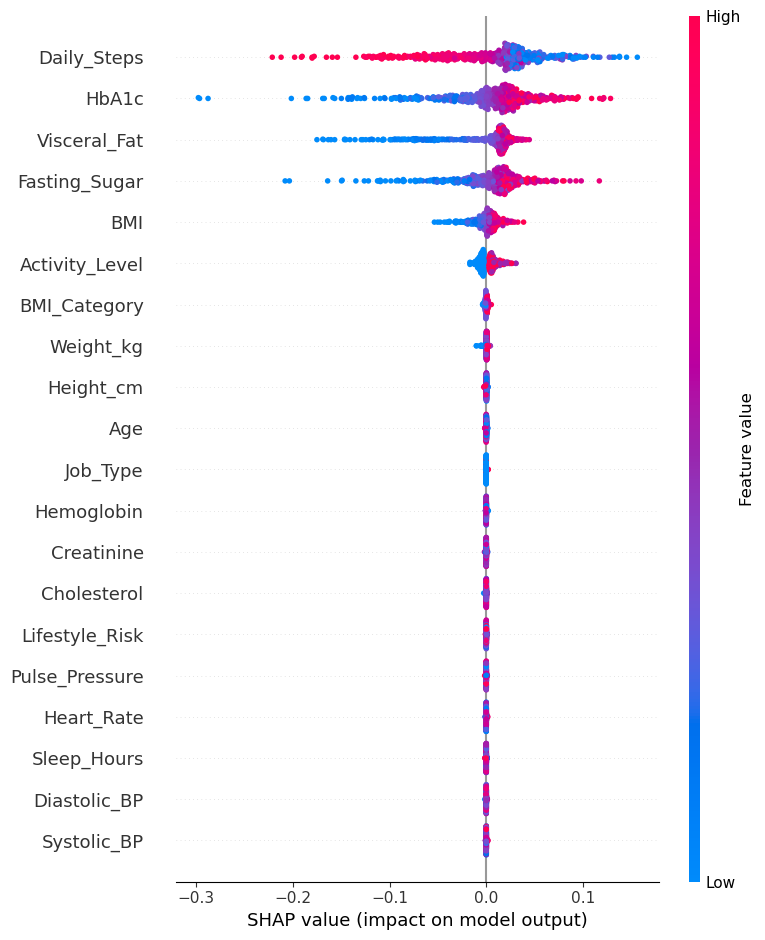

In [23]:
shap.summary_plot(shap_values, sample_data)

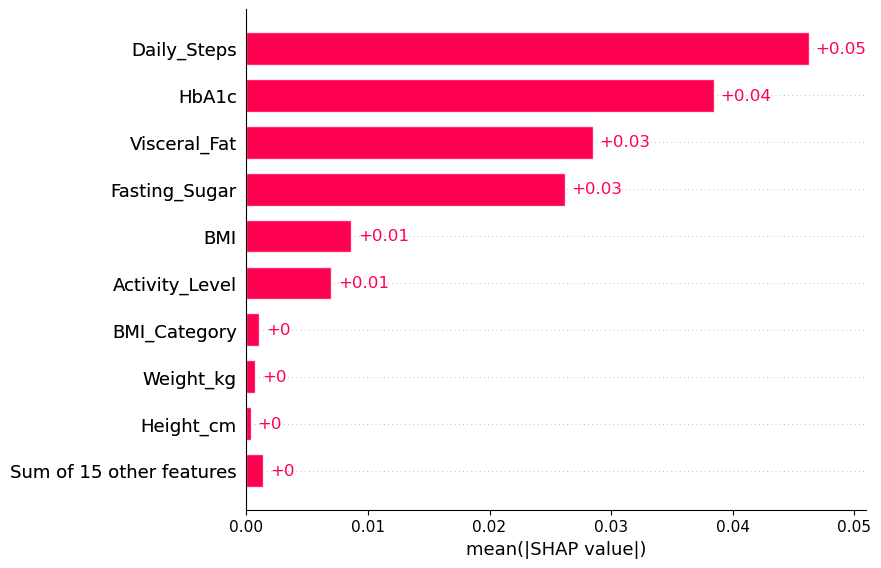

In [24]:
shap.plots.bar(shap_values)

# Recreating pkl Files(All you need for simple but working GUI for the model) 

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
final_model.fit(X_train_scaled, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [28]:
import joblib

joblib.dump(final_model, "final_disease_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("✅ Model + Scaler + Columns saved")

✅ Model + Scaler + Columns saved


In [29]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>
